# Exploración de datos

## Carga de dataset

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import seaborn as sns

In [2]:
# enable cuda processing for sklearn
import os
os.environ["SKLEARN_ENABLE_CUDA"] = "1"

In [3]:
# DATASET PATH
PATH = "./datasets/01_bo_vip_seed22_n100000.csv"

# LOAD DATASET
df = pd.read_csv(PATH)

# CHECK DATASET
df.head()

,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,...,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud
0,7dd812b1-bd03-4d05-afc6-c318dcc9b651,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00001325,PLATINUM,POS,MASTERCARD,531270******3773,...,500.12,True,8717.0,20,Tue,True,Approved,2012.51,TARIJA,False
1,c08b49a6-889a-491a-a1f8-974526f7886d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000079,PRIVATE,ECOM,VISA,421250******5552,...,1898.93,False,4.9,20,Tue,True,Approved,1096.46,LAPAZ,False
2,b04f88bd-2e33-42e5-a3cf-d52ef22dd7d9,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002344,INFINITE,ECOM,NaN,531270******6104,...,349.85,False,4.4,20,Tue,True,Approved,1528.37,SANTACRUZ,False
3,3a836c25-7a8c-473b-8141-3e84ba3f212d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002587,PLATINUM,ATM,VISA,479500******0288,...,345.58,True,3966.0,20,Tue,True,Approved,2483.34,SUCRE,False
4,be9956da-924f-4c68-aed8-f0c5d949e577,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000087,PRIVATE,POS,VISA,479500******0249,...,118.90,False,348.0,20,Tue,True,NaN,1334.55,SUCRE,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100003 entries, 0 to 100002
Data columns (total 66 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   transaction_id                    100003 non-null  object 
 1   bank_code                         100003 non-null  object 
 2   bank_name                         100003 non-null  object 
 3   bank_country                      100003 non-null  object 
 4   bank_tier                         100003 non-null  object 
 5   client_id                         100003 non-null  object 
 6   client_segment                    98957 non-null   object 
 7   channel                           100003 non-null  object 
 8   card_brand                        98961 non-null   object 
 9   pan_masked                        100003 non-null  object 
 10  pan_hash                          100003 non-null  object 
 11  MTI                               100003 non-null  i

## Manejo de nulos

<Axes: >

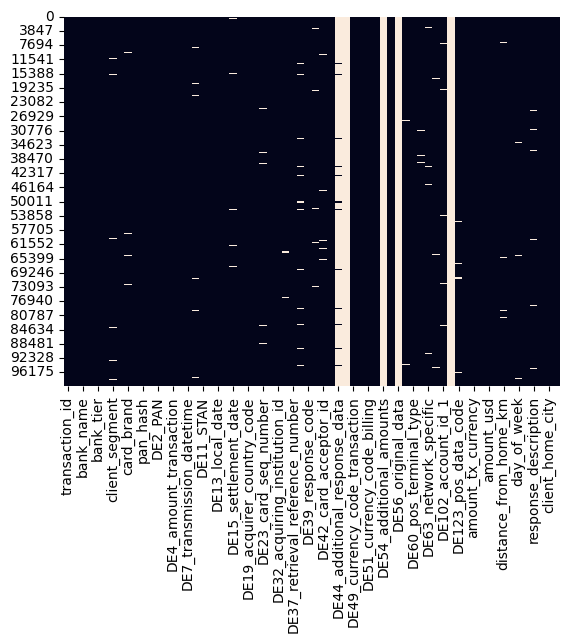

In [5]:
# nulls heatmap
sns.heatmap(df.isnull(), cbar=False)

In [6]:
# Columns with null values
null_columns = df.columns[df.isnull().any()]
print("Columns with null values:")
for e in null_columns:
    print(f"{e}: {df[e].isnull().sum()/len(df):.2%}")

Columns with null values:
client_segment: 1.05%
card_brand: 1.04%
DE9_conversion_rate_billing: 1.00%
DE15_settlement_date: 0.98%
DE23_card_seq_number: 1.04%
DE35_track2_data_masked: 1.03%
DE38_authorization_code: 3.27%
DE41_terminal_id: 1.02%
DE42_card_acceptor_id: 1.00%
DE44_additional_response_data: 96.73%
DE48_additional_data: 100.00%
DE54_additional_amounts: 100.00%
DE56_original_data: 100.00%
DE58_authorizing_agent_id: 1.01%
DE61_pos_extended_data: 1.02%
DE63_network_specific: 1.04%
DE100_receiving_institution_id: 1.05%
DE102_account_id_1: 1.03%
DE103_account_id_2: 100.00%
DE123_pos_data_code: 0.95%
distance_from_home_km: 0.98%
day_of_week: 1.00%
response_description: 0.99%


Las columnas: DE48_additional_data, DE54_additional_amounts, DE56_original_data y DE103_account_id_2 se pueden descartar, pues contienen únicamente valores nulos.

In [7]:
# Columns to drop: DE48_additional_data, DE54_additional_amounts, DE56_original_data y DE103_account_id_2
columns_to_drop = ["DE48_additional_data", "DE54_additional_amounts", "DE56_original_data", "DE103_account_id_2"]
df.drop(columns=columns_to_drop, inplace=True)

In [8]:
# Check if there are any remaining null values
null_columns = df.columns[df.isnull().any()]
print("Columns with more than 50% null values:")
for e in null_columns:
    null_percentage = df[e].isnull().sum() / len(df)
    if null_percentage > 0.5:
        print(f"{e}: {null_percentage:.2%} (consider dropping this column)")

Columns with more than 50% null values:
DE44_additional_response_data: 96.73% (consider dropping this column)


In [9]:
# unique values of column DE44_additional_response_data
print("Unique values of column DE44_additional_response_data:")
print(df["DE44_additional_response_data"].unique())

Unique values of column DE44_additional_response_data:
[nan 'INCORRECT PIN' 'EXPIRED CARD' 'DO NOT HONOR' 'SYSTEM MALFUNCTION'
 'RESTRICTED CARD' 'INSUFFICIENT FUNDS' 'ISSUER OR SWITCH INOPERAT'
 'TRANSACTION NOT PERMITTED' 'INVALID CARD NUMBER'
 'EXCEEDS WITHDRAWAL AMOUNT']


La columna DE44_additional_response_data está mayormente plagada de nulos, sin información particularmente crítica, por lo que la descartamos.

In [10]:
drop_columns = ["DE44_additional_response_data"]
df.drop(columns=drop_columns, inplace=True)

In [11]:
# Amount of rows with null values in any column
null_rows = df[df.isnull().any(axis=1)]
print(f"Percentage of rows with null values in any column: {len(null_rows)/len(df)*100:.2f}%")

Percentage of rows with null values in any column: 18.68%


Hay demasiadas filas con valores nulos para sólo eliminar los registros con valores nulos.

In [12]:
# amount of unique values in null_columns
null_columns = df.columns[df.isnull().any()]
for e in null_columns:
    print(f"{e}: {df[e].nunique()} unique values") 

client_segment: 4 unique values
card_brand: 2 unique values
DE9_conversion_rate_billing: 10797 unique values
DE15_settlement_date: 181 unique values
DE23_card_seq_number: 3 unique values
DE35_track2_data_masked: 3992 unique values
DE38_authorization_code: 96735 unique values
DE41_terminal_id: 994 unique values
DE42_card_acceptor_id: 500 unique values
DE58_authorizing_agent_id: 1 unique values
DE61_pos_extended_data: 4 unique values
DE63_network_specific: 1 unique values
DE100_receiving_institution_id: 1 unique values
DE102_account_id_1: 4000 unique values
DE123_pos_data_code: 8 unique values
distance_from_home_km: 10683 unique values
day_of_week: 7 unique values
response_description: 12 unique values


In [13]:
# Null summary after dropping columns with >90% nulls

null_summary = (
    df.isnull()
    .sum()
    .reset_index()
)

null_summary.columns = ["column", "missing_count"]
null_summary["missing_percentage"] = (null_summary["missing_count"] / len(df)) * 100
null_summary = null_summary[null_summary["missing_count"] > 0]
null_summary = null_summary.sort_values(by="missing_percentage", ascending=False)

null_summary

,column,missing_count,missing_percentage
31,DE38_authorization_code,3267,3.266902
45,DE100_receiving_institution_id,1050,1.049969
6,client_segment,1046,1.045969
44,DE63_network_specific,1045,1.044969
8,card_brand,1042,1.041969
26,DE23_card_seq_number,1038,1.037969
46,DE102_account_id_1,1035,1.034969
29,DE35_track2_data_masked,1029,1.028969
43,DE61_pos_extended_data,1025,1.024969
33,DE41_terminal_id,1025,1.024969


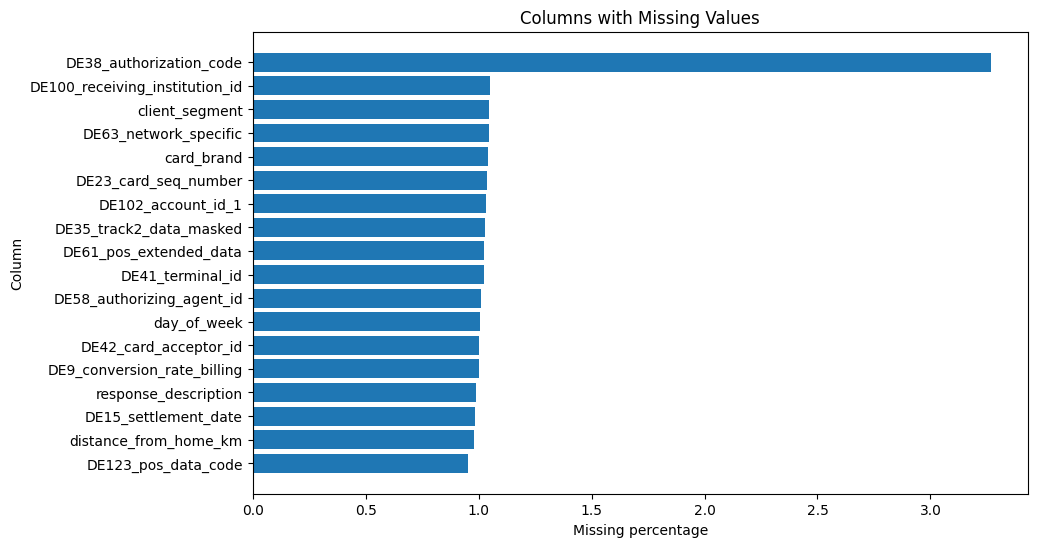

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(null_summary["column"], null_summary["missing_percentage"])
plt.xlabel("Missing percentage")
plt.ylabel("Column")
plt.title("Columns with Missing Values")
plt.gca().invert_yaxis()
plt.show()

In [15]:
# Placeholder value for nulls in all columns with nulls so we can do a heatmap of correlations between all columns
for e in null_columns:
    df[e].fillna("____D____missing", inplace=True)


C:\Users\diego\AppData\Local\Temp\ipykernel_9256\417202747.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[e].fillna("____D____missing", inplace=True)
C:\Users\diego\AppData\Local\Temp\ipykernel_9256\417202747.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '____D____missing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df[e].fillna("____D____missing", inplace=True)


In [16]:
# which columns are categorical and which are numerical
categorical_columns = df.select_dtypes(include=["object", "bool"]).columns
numerical_columns = df.select_dtypes(include=["number"]).columns
print("Categorical columns:", categorical_columns.tolist())
print("\nNumerical columns:", numerical_columns.tolist())
print(f"Total columns: {len(df.columns)}, Categorical: {len(categorical_columns)}, Numerical: {len(numerical_columns)}")   

Categorical columns: ['transaction_id', 'bank_code', 'bank_name', 'bank_country', 'bank_tier', 'client_id', 'client_segment', 'channel', 'card_brand', 'pan_masked', 'pan_hash', 'DE9_conversion_rate_billing', 'DE15_settlement_date', 'DE23_card_seq_number', 'DE35_track2_data_masked', 'DE37_retrieval_reference_number', 'DE38_authorization_code', 'DE41_terminal_id', 'DE42_card_acceptor_id', 'DE43_card_acceptor_name_location', 'DE52_pin_data_present', 'DE55_emv_data_present', 'DE58_authorizing_agent_id', 'DE60_pos_terminal_type', 'DE61_pos_extended_data', 'DE63_network_specific', 'DE100_receiving_institution_id', 'DE102_account_id_1', 'DE123_pos_data_code', 'currency_tx_alpha', 'is_international', 'distance_from_home_km', 'day_of_week', 'approved', 'response_description', 'client_home_city', 'is_fraud']

Numerical columns: ['MTI', 'DE2_PAN', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE11_STAN', 'DE12_local_time', 'DE13_lo

## Exploración de variables

In [17]:
# Numerical columns exploration
for col in numerical_columns:
    print(f"Column: {col}")
    print(f"  Mean: {df[col].mean()}")
    print(f"  Std: {df[col].std()}")
    print(f"  Min: {df[col].min()}")
    print(f"  25%: {df[col].quantile(0.25)}")
    print(f"  50%: {df[col].median()}")
    print(f"  75%: {df[col].quantile(0.75)}")
    print(f"  Max: {df[col].max()}")
    print(f"  Unique values: {df[col].nunique()}")
    print()

Column: MTI
  Mean: 100.0
  Std: 0.0
  Min: 100
  25%: 100.0
  50%: 100.0
  75%: 100.0
  Max: 100
  Unique values: 1

Column: DE2_PAN
  Mean: 4770995793526194.0
  Std: 449807652044962.75
  Min: 4212500000000000.0
  25%: 4212510000000000.0
  50%: 4795000000000000.0
  75%: 5312700000000000.0
  Max: 5312710000000000.0
  Unique values: 6

Column: DE3_processing_code
  Mean: 3424.7972560823177
  Std: 23391.24769798025
  Min: 0
  25%: 0.0
  50%: 0.0
  75%: 0.0
  Max: 300000
  Unique values: 5

Column: DE4_amount_transaction
  Mean: 1426779.4781756548
  Std: 11549812.853514384
  Min: 7
  25%: 37047.5
  50%: 111250.0
  75%: 301340.0
  Max: 491181942
  Unique values: 86906

Column: DE6_amount_cardholder_billing
  Mean: 297121.5671829845
  Std: 412548.26699721476
  Min: 50
  25%: 58131.5
  50%: 138299.0
  75%: 333917.0
  Max: 4645012
  Unique values: 89499

Column: DE7_transmission_datetime
  Mean: 365021387.8456146
  Std: 170810563.7629346
  Min: 101000151
  25%: 214201183.5
  50%: 331223341.0


Columnas con sólo 1 valor único se traduce a un valor constante, y por tanto no brinda información particular.

In [18]:
# Drop columns with only one unique value (no variance)
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"Dropping column {col} because it has only one unique value")
        df.drop(columns=[col], inplace=True)

Dropping column bank_code because it has only one unique value
Dropping column bank_name because it has only one unique value
Dropping column bank_country because it has only one unique value
Dropping column bank_tier because it has only one unique value
Dropping column MTI because it has only one unique value
Dropping column DE32_acquiring_institution_id because it has only one unique value
Dropping column DE50_currency_code_settlement because it has only one unique value
Dropping column DE51_currency_code_billing because it has only one unique value


<Axes: >

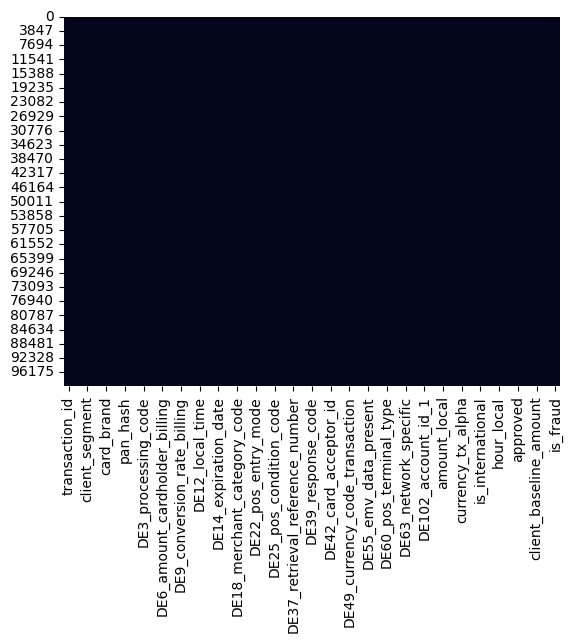

In [19]:
# update categorical and numerical columns after dropping columns with only one unique value
categorical_columns = df.select_dtypes(include=["object", "bool"]).columns
numerical_columns = df.select_dtypes(include=["number"]).columns

sns.heatmap(df.isnull(), cbar=False)

In [20]:
# Amount of unique values in each categorical column
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

transaction_id: 100003 unique values
client_id: 4000 unique values
client_segment: 5 unique values
channel: 4 unique values
card_brand: 3 unique values
pan_masked: 3735 unique values
pan_hash: 4000 unique values
DE9_conversion_rate_billing: 10798 unique values
DE15_settlement_date: 182 unique values
DE23_card_seq_number: 4 unique values
DE35_track2_data_masked: 3993 unique values
DE37_retrieval_reference_number: 100003 unique values
DE38_authorization_code: 96736 unique values
DE41_terminal_id: 995 unique values
DE42_card_acceptor_id: 501 unique values
DE43_card_acceptor_name_location: 1708 unique values
DE52_pin_data_present: 2 unique values
DE55_emv_data_present: 2 unique values
DE58_authorizing_agent_id: 2 unique values
DE60_pos_terminal_type: 4 unique values
DE61_pos_extended_data: 5 unique values
DE63_network_specific: 2 unique values
DE100_receiving_institution_id: 2 unique values
DE102_account_id_1: 4001 unique values
DE123_pos_data_code: 9 unique values
currency_tx_alpha: 6 uni

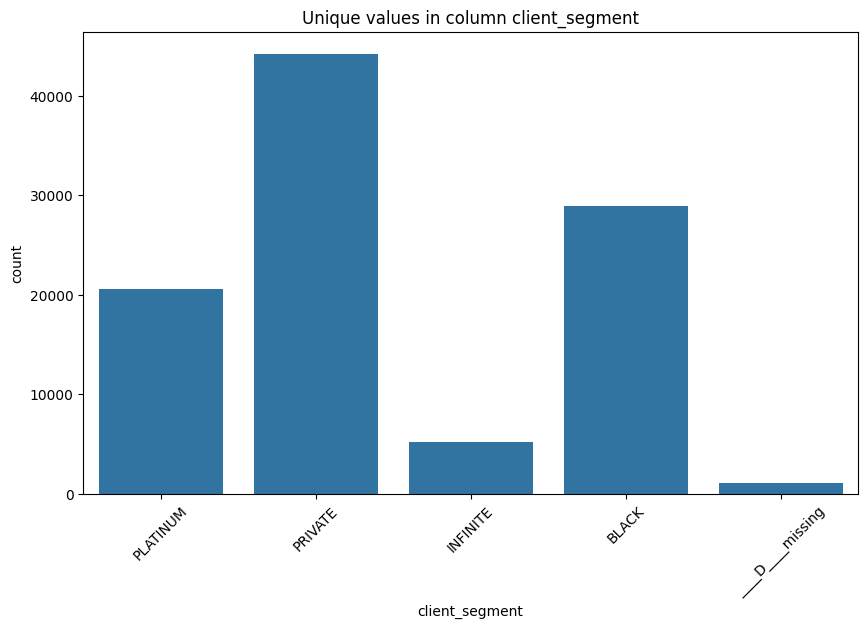

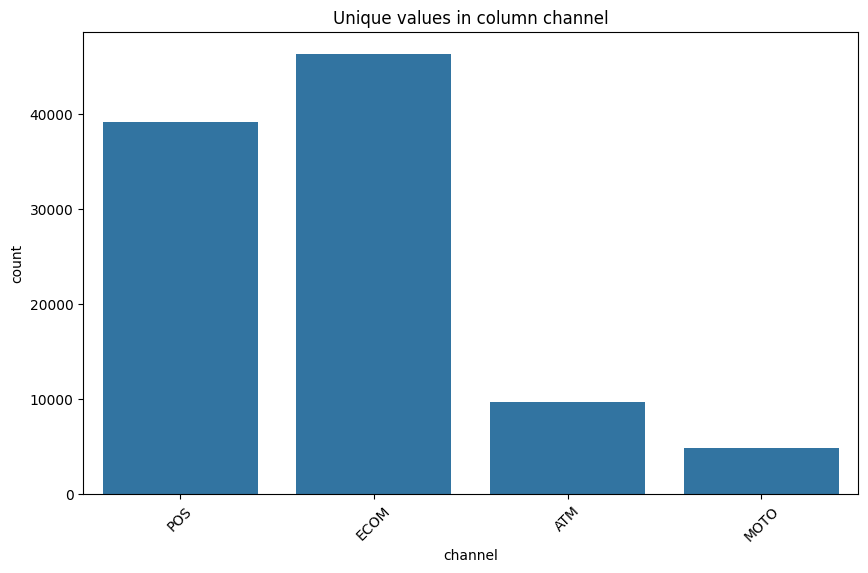

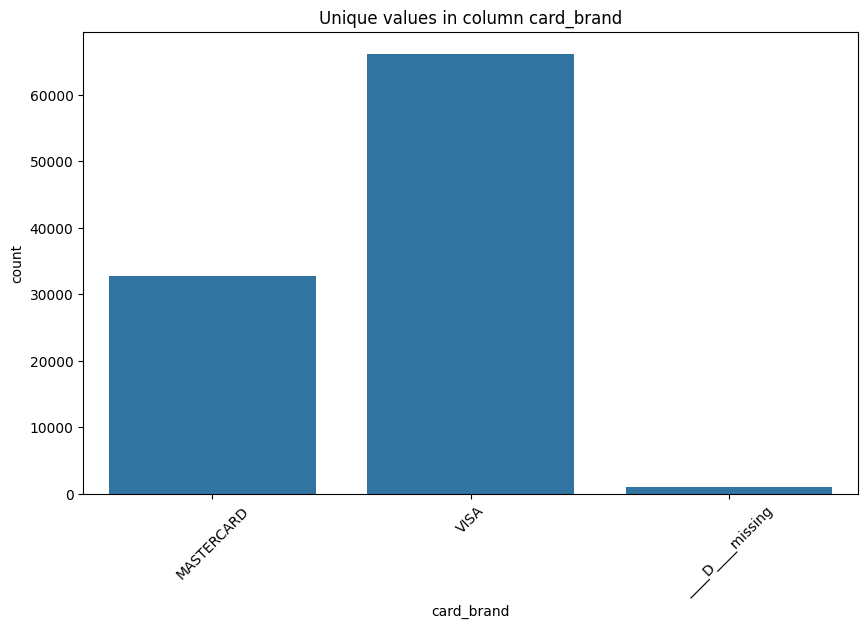

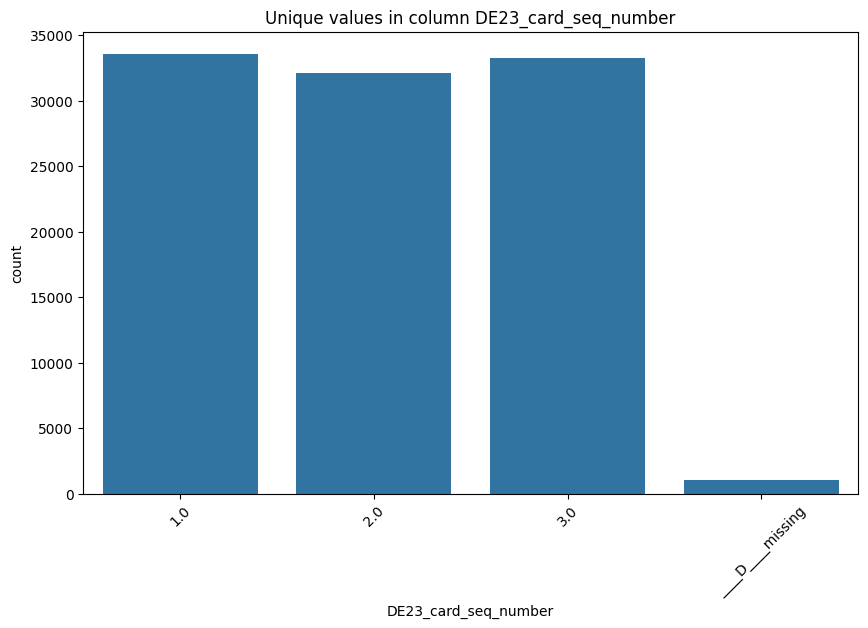

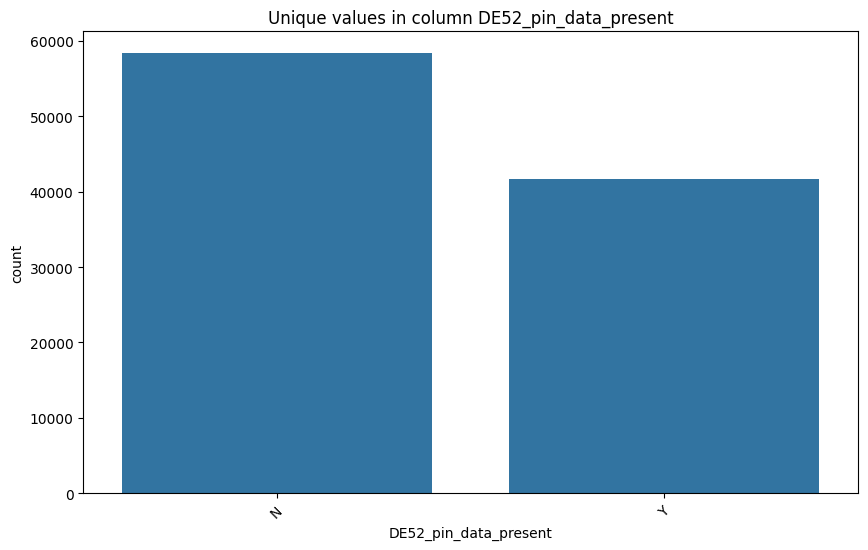

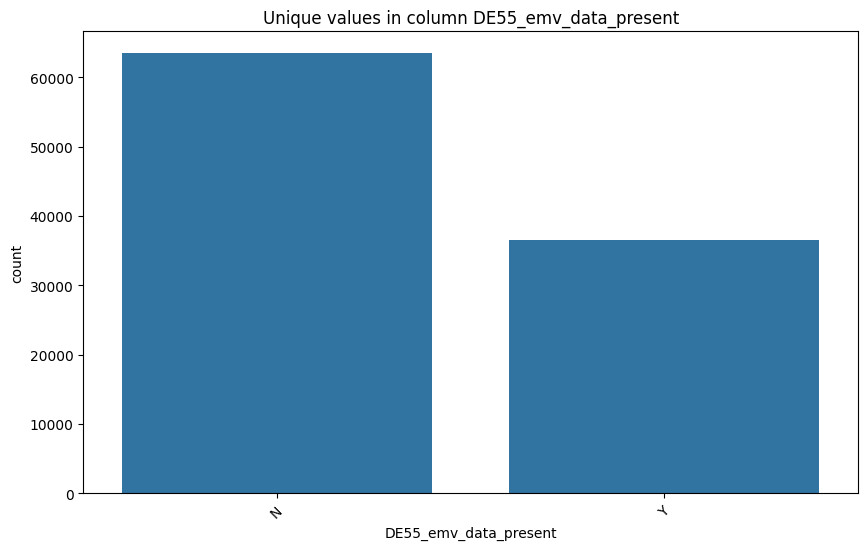

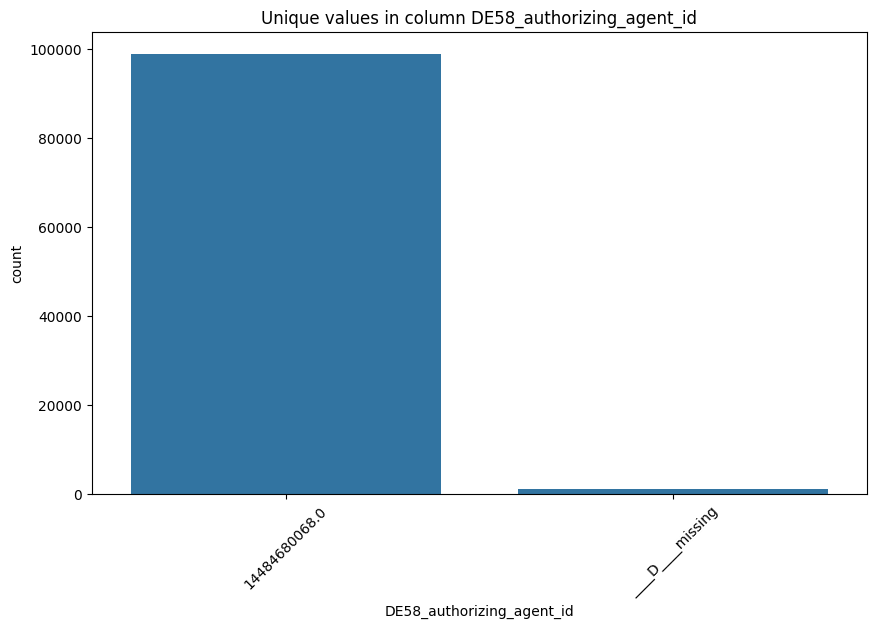

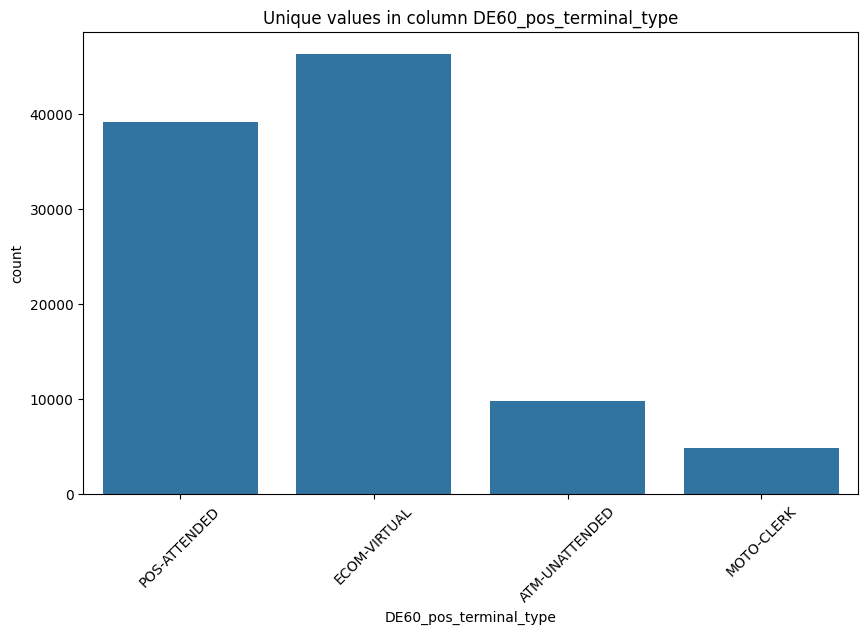

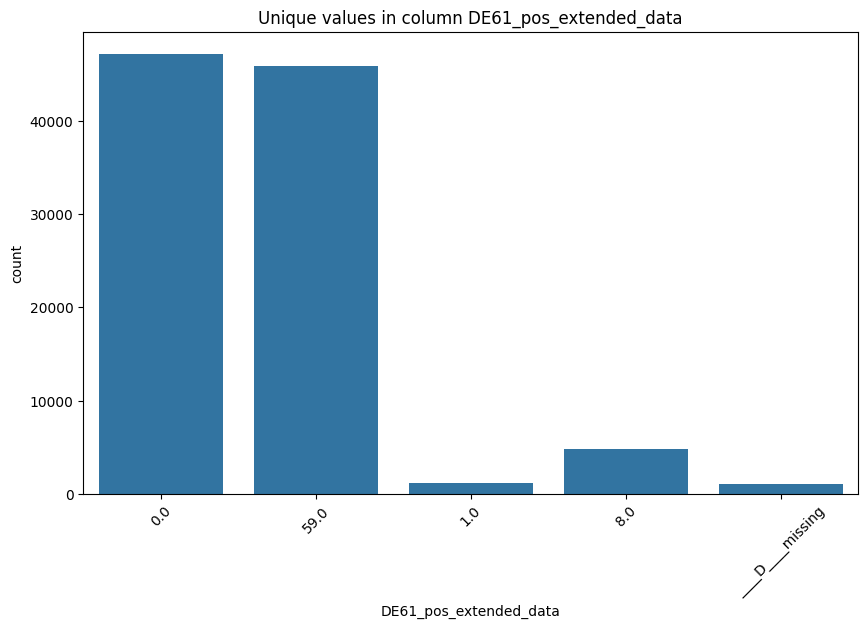

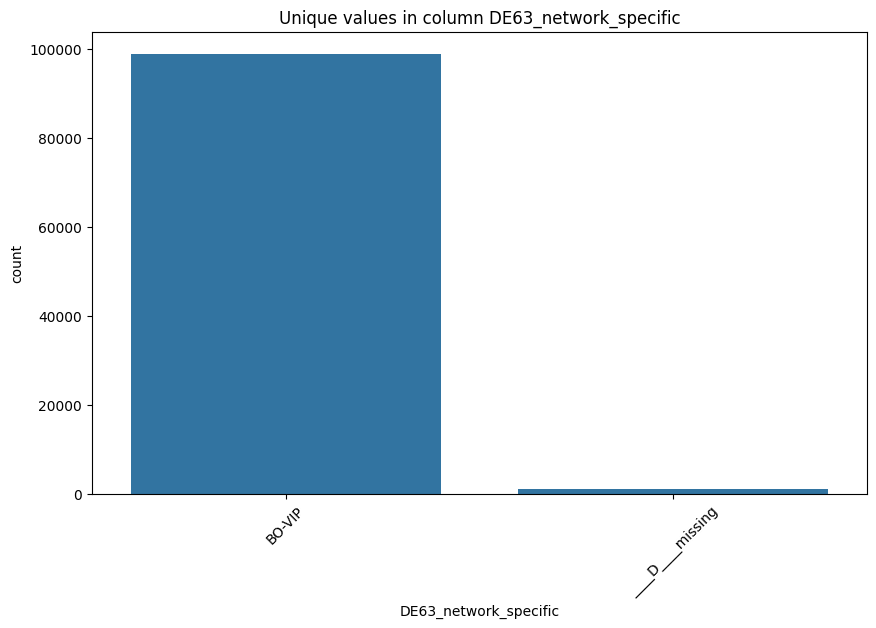

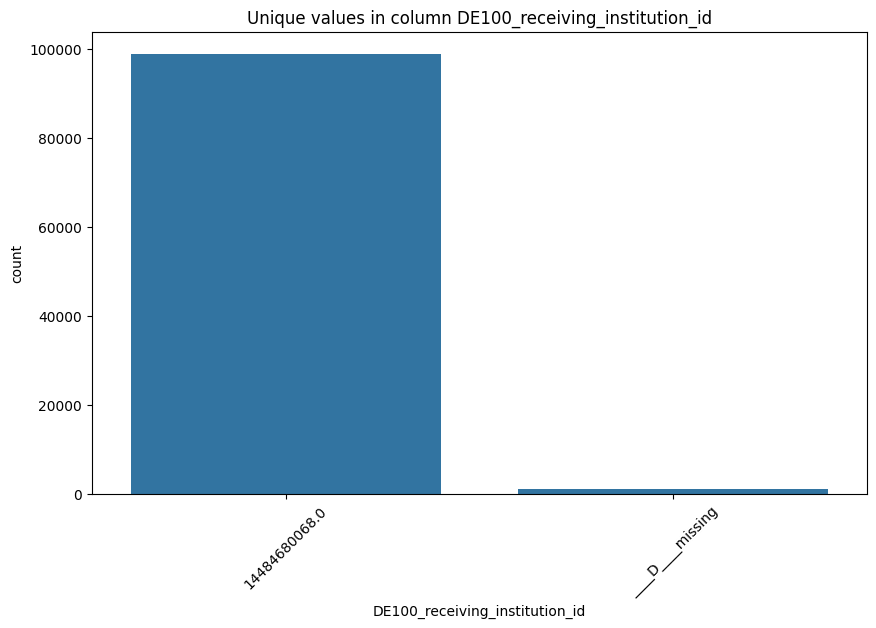

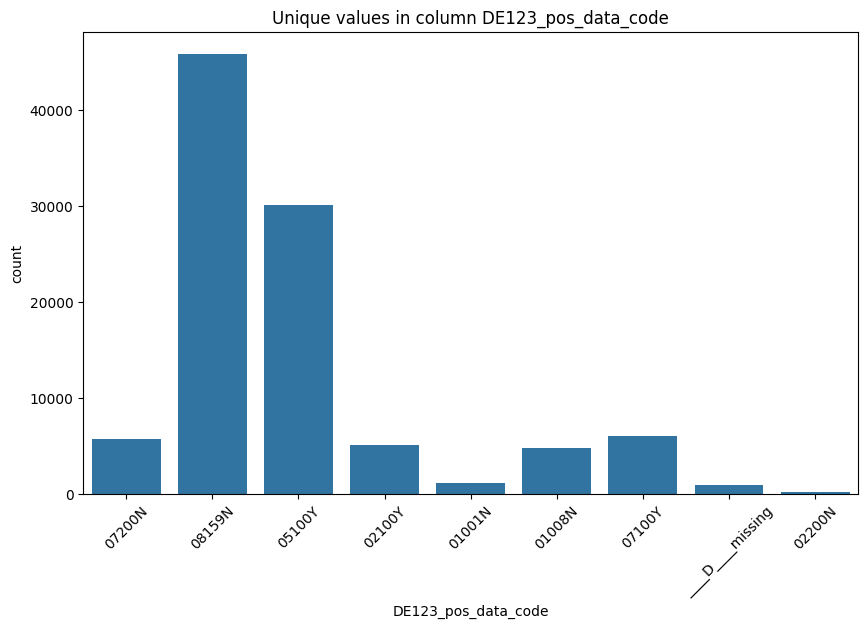

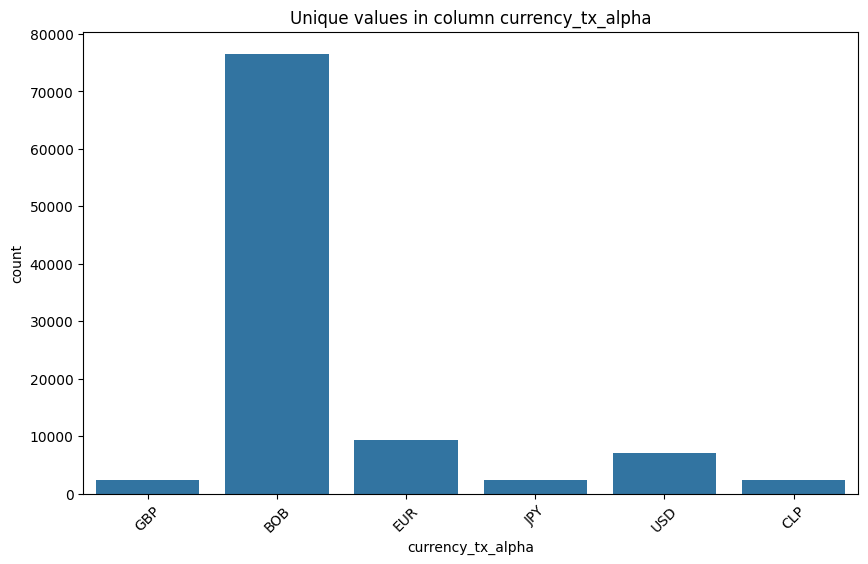

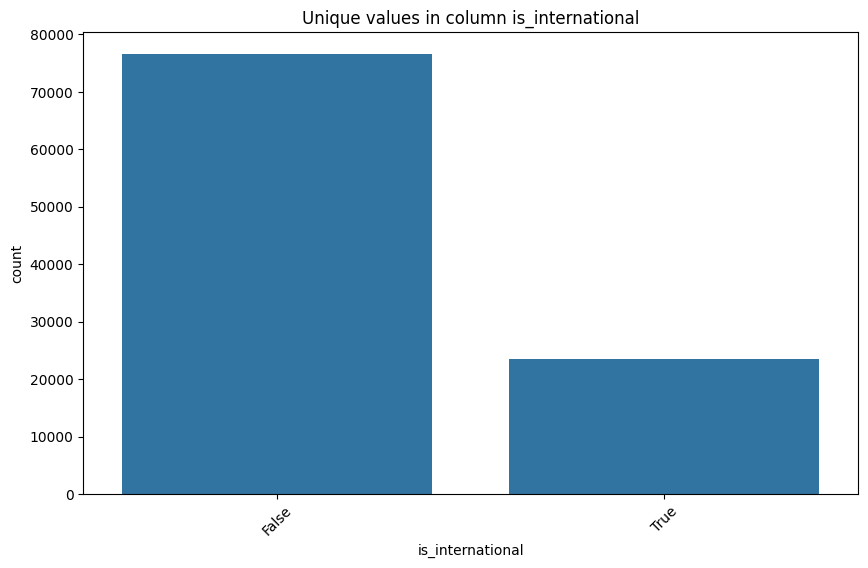

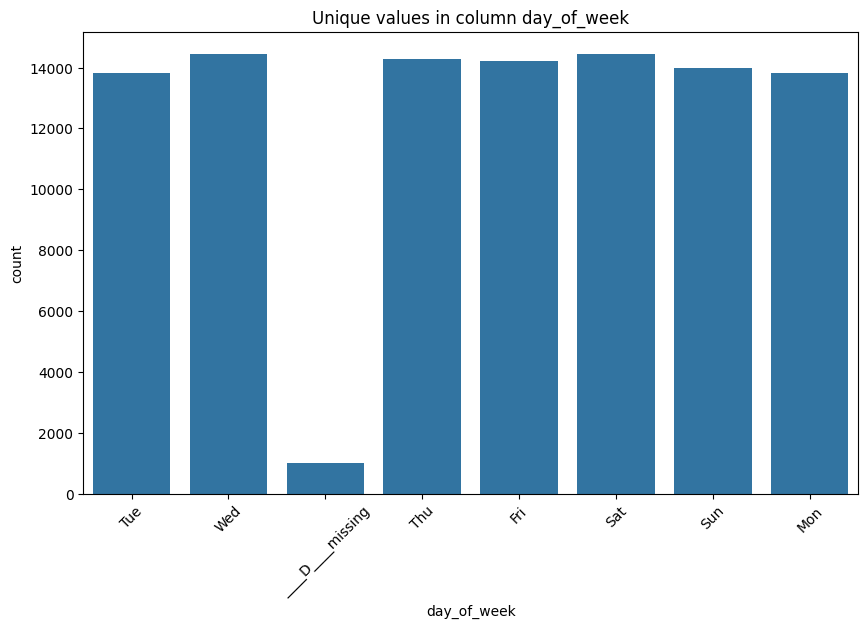

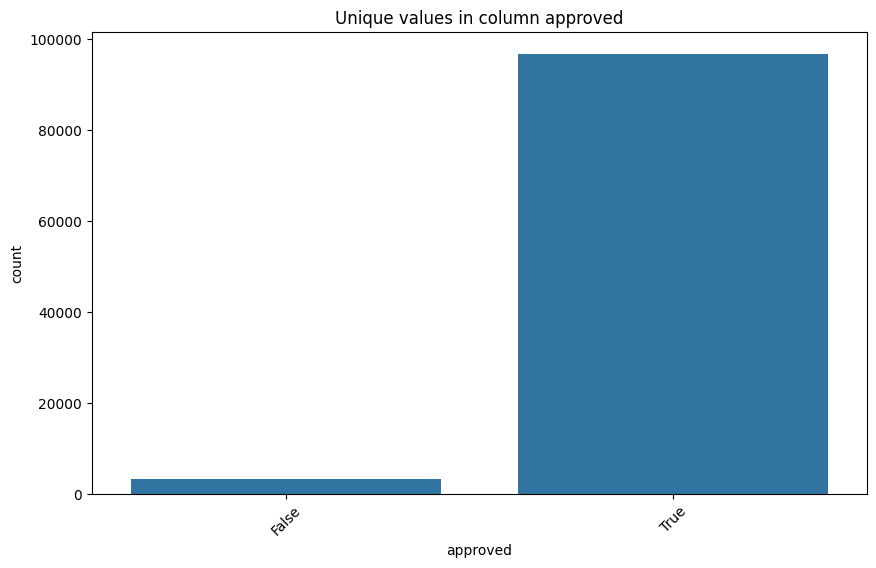

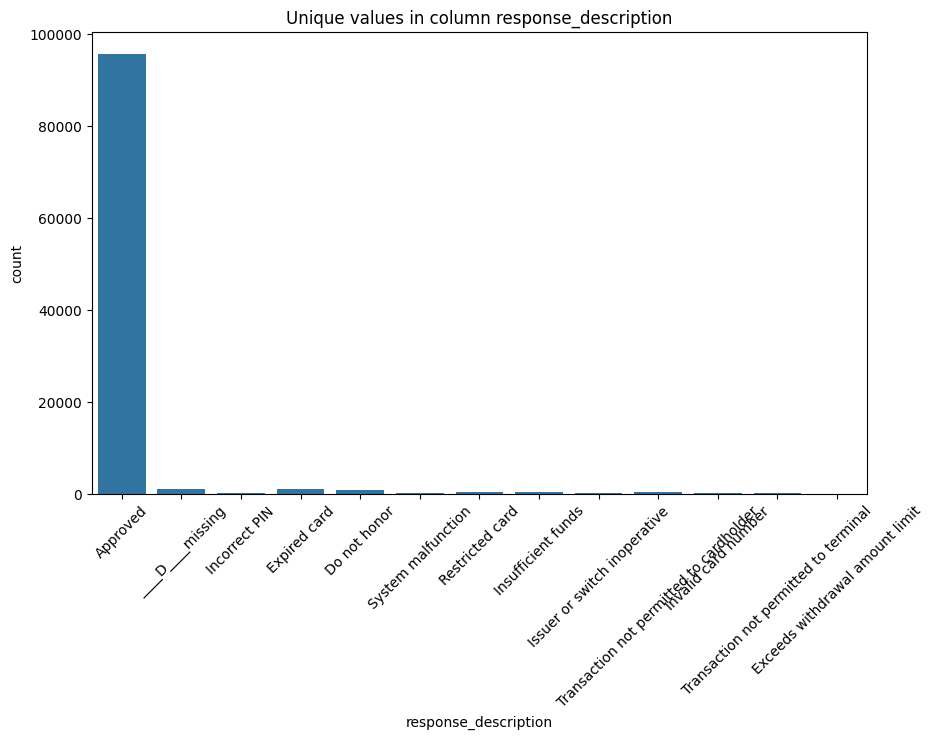

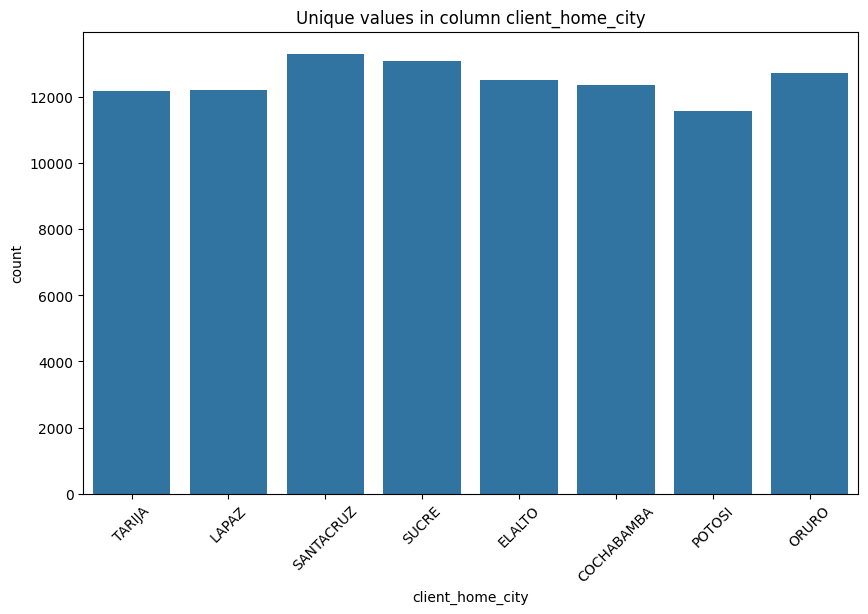

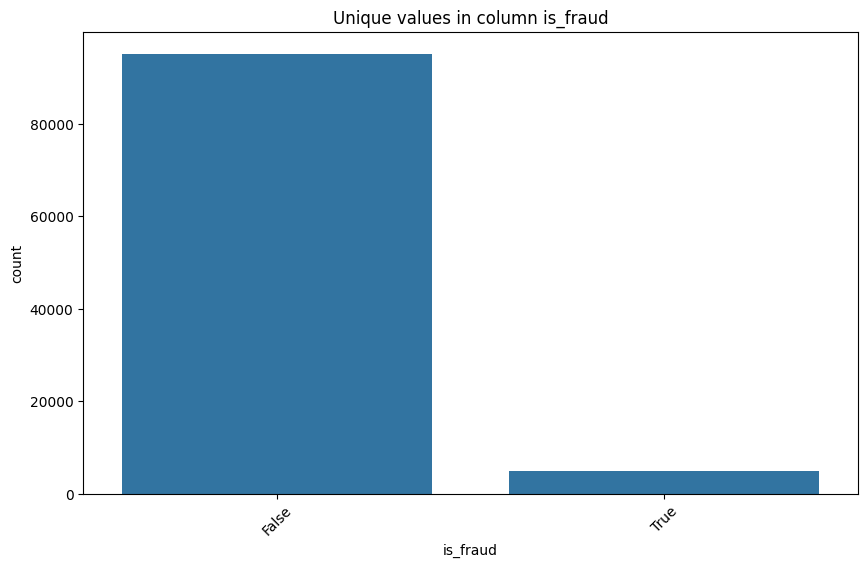

In [21]:
# bar plot of unique values in categorical columns for columns with less than 20 unique values
for col in categorical_columns:
    if df[col].nunique() < 20:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x=col)
        plt.title(f"Unique values in column {col}")
        plt.xticks(rotation=45)
        plt.show()

In [22]:
# Columns with more than 20 unique values
for col in categorical_columns:
    if df[col].nunique() >= 20:
        print(f"{col}: {df[col].nunique()} unique values")

transaction_id: 100003 unique values
client_id: 4000 unique values
pan_masked: 3735 unique values
pan_hash: 4000 unique values
DE9_conversion_rate_billing: 10798 unique values
DE15_settlement_date: 182 unique values
DE35_track2_data_masked: 3993 unique values
DE37_retrieval_reference_number: 100003 unique values
DE38_authorization_code: 96736 unique values
DE41_terminal_id: 995 unique values
DE42_card_acceptor_id: 501 unique values
DE43_card_acceptor_name_location: 1708 unique values
DE102_account_id_1: 4001 unique values
distance_from_home_km: 10684 unique values


In [23]:
# columns with the same amount of uniques as the number of rows are id columns and should be dropped, because they don't provide any useful information for the model
for col in categorical_columns:
    if df[col].nunique() == len(df):
        print(f"Dropping column {col} because it has the same amount of unique values as the number of rows")
        df.drop(columns=[col], inplace=True)
        categorical_columns = categorical_columns.drop(col)

Dropping column transaction_id because it has the same amount of unique values as the number of rows
Dropping column DE37_retrieval_reference_number because it has the same amount of unique values as the number of rows


In [24]:
# show variance of columns where DE38_authorization_code has the placeholder value for nulls, which is ____D____missing, and is_fraud is True, 
# to see if there are any patterns in the data that could indicate that this column is important for the model

cases = df[(df["DE38_authorization_code"] == "____D____missing") & (df["is_fraud"] == True)]
print(f"Number of cases where DE38_authorization_code is ____D____missing and is_fraud is True: {len(cases)}")

# variance of numerical columns in cases where DE38_authorization_code is ____D____missing and is_fraud is True
for col in numerical_columns:
    variance = cases[col].var()
    print(f" - Variance of column {col} in this scenario: {variance}. {'HIGH!' if variance > 10 else 'LOW!'}")
    print(f"   - {col} has {cases[col].nunique()} unique values in these cases.")
    print(f"   - {col} has overall variance of {df[col].var()} and {df[col].nunique()} unique values in the whole dataset.")


Number of cases where DE38_authorization_code is ____D____missing and is_fraud is True: 1560
 - Variance of column DE2_PAN in this scenario: 2.039146683411654e+29. HIGH!
   - DE2_PAN has 6 unique values in these cases.
   - DE2_PAN has overall variance of 2.0232692383820228e+29 and 6 unique values in the whole dataset.
 - Variance of column DE3_processing_code in this scenario: 295231616.2563116. HIGH!
   - DE3_processing_code has 5 unique values in these cases.
   - DE3_processing_code has overall variance of 547150468.8682663 and 5 unique values in the whole dataset.
 - Variance of column DE4_amount_transaction in this scenario: 1335560520637798.5. HIGH!
   - DE4_amount_transaction has 1536 unique values in these cases.
   - DE4_amount_transaction has overall variance of 133398176951206.08 and 86906 unique values in the whole dataset.
 - Variance of column DE6_amount_cardholder_billing in this scenario: 612667462579.3982. HIGH!
   - DE6_amount_cardholder_billing has 1535 unique value

In [25]:
# Find columns where we only have two unique values and one of them is the placeholder value for nulls, which is ____D____missing, to see if there are any patterns in the data that could indicate that these columns are important for the model

for col in categorical_columns:
    if df[col].nunique() == 2 and "____D____missing" in df[col].unique():
        print(f"Column {col} has only two unique values and one of them is the placeholder value for nulls.")
        print(f" - Unique values: {df[col].unique()}")
        print(f" - Value counts:\n{df[col].value_counts()}")

Column DE58_authorizing_agent_id has only two unique values and one of them is the placeholder value for nulls.
 - Unique values: [14484680068.0 '____D____missing']
 - Value counts:
DE58_authorizing_agent_id
14484680068.0       98991
____D____missing     1012
Name: count, dtype: int64
Column DE63_network_specific has only two unique values and one of them is the placeholder value for nulls.
 - Unique values: ['BO-VIP' '____D____missing']
 - Value counts:
DE63_network_specific
BO-VIP              98958
____D____missing     1045
Name: count, dtype: int64
Column DE100_receiving_institution_id has only two unique values and one of them is the placeholder value for nulls.
 - Unique values: [14484680068.0 '____D____missing']
 - Value counts:
DE100_receiving_institution_id
14484680068.0       98953
____D____missing     1050
Name: count, dtype: int64


In [26]:
# Drop columns DE58_authorizing_agent_id, DE63_network_specific and DE100_receiving_institution_id
drop_columns = ["DE58_authorizing_agent_id", "DE63_network_specific", "DE100_receiving_institution_id"]
for col in drop_columns:
    if col in df.columns:
        print(f"Dropping column {col} because it has only two unique values and one of them is the placeholder value for nulls.")
        df.drop(columns=[col], inplace=True)


# update categorical and numerical
categorical_columns = df.select_dtypes(include=["object", "bool"]).columns
numerical_columns = df.select_dtypes(include=["number"]).columns

df.info()

Dropping column DE58_authorizing_agent_id because it has only two unique values and one of them is the placeholder value for nulls.
Dropping column DE63_network_specific because it has only two unique values and one of them is the placeholder value for nulls.
Dropping column DE100_receiving_institution_id because it has only two unique values and one of them is the placeholder value for nulls.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100003 entries, 0 to 100002
Data columns (total 48 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   client_id                         100003 non-null  object 
 1   client_segment                    100003 non-null  object 
 2   channel                           100003 non-null  object 
 3   card_brand                        100003 non-null  object 
 4   pan_masked                        100003 non-null  object 
 5   pan_hash                          10000

In [27]:
# drop client_id
if "client_id" in df.columns:
    print("Dropping column client_id because it has the same amount of unique values as the number of rows.")
    df.drop(columns=["client_id"], inplace=True)

# update categorical and numerical columns after dropping client_id
categorical_columns = df.select_dtypes(include=["object", "bool"]).columns
numerical_columns = df.select_dtypes(include=["number"]).columns

# Columns with more than 20 unique values
print("Columns with more than 20 unique values:")
less_than_20_unique = []
for col in categorical_columns:
    if df[col].nunique() >= 20:
        print(f"{col}: {df[col].nunique()} unique values")
    else:
        less_than_20_unique.append(col)

print("/"*100)
print("Columns with less than 20 unique values:")
for col in less_than_20_unique:
    print(f"{col}: {df[col].nunique()} unique values")

Dropping column client_id because it has the same amount of unique values as the number of rows.
Columns with more than 20 unique values:
pan_masked: 3735 unique values
pan_hash: 4000 unique values
DE9_conversion_rate_billing: 10798 unique values
DE15_settlement_date: 182 unique values
DE35_track2_data_masked: 3993 unique values
DE38_authorization_code: 96736 unique values
DE41_terminal_id: 995 unique values
DE42_card_acceptor_id: 501 unique values
DE43_card_acceptor_name_location: 1708 unique values
DE102_account_id_1: 4001 unique values
distance_from_home_km: 10684 unique values
////////////////////////////////////////////////////////////////////////////////////////////////////
Columns with less than 20 unique values:
client_segment: 5 unique values
channel: 4 unique values
card_brand: 3 unique values
DE23_card_seq_number: 4 unique values
DE52_pin_data_present: 2 unique values
DE55_emv_data_present: 2 unique values
DE60_pos_terminal_type: 4 unique values
DE61_pos_extended_data: 5 uni

Los IDs en general no son útiles para identificar comportamiento o patrones.

In [28]:
to_drop = ['DE41_terminal_id', 'DE42_card_acceptor_id', 'DE43_card_acceptor_name_location', 'DE102_account_id_1', 'DE38_authorization_code', 'DE35_track2_data_masked']
    
for col in to_drop:
    if col in df.columns:
        print(f"Dropping column {col}.")
        df.drop(columns=[col], inplace=True)

Dropping column DE41_terminal_id.
Dropping column DE42_card_acceptor_id.
Dropping column DE43_card_acceptor_name_location.
Dropping column DE102_account_id_1.
Dropping column DE38_authorization_code.
Dropping column DE35_track2_data_masked.


In [29]:
# pan and pan hash, although they identify accounts, do not provide useful information for the model, because they are unique for each transaction and therefore don't provide any patterns that the model can learn from, so they should be dropped.
pan_drop= ['pan_masked', 'pan_hash']

for col in pan_drop:
    if col in df.columns:
        print(f"Dropping column {col}.")
        df.drop(columns=[col], inplace=True)

Dropping column pan_masked.
Dropping column pan_hash.


In [30]:
# shwocase the values and distribution of values for the columns: DE9_conversion_rate_billing, DE15_settlement_date, distance_from_home_km
columns_to_show = ['DE9_conversion_rate_billing', 'DE15_settlement_date', 'distance_from_home_km']
for col in columns_to_show:
    if col in df.columns:
        print(f"Column: {col}")
        print(f"Unique values: {df[col].nunique()}")
        print(f"Amount of null placeholders (____D____missing ): {df[col].value_counts().get('____D____missing', 0)} = {df[col].value_counts().get('____D____missing', 0)/len(df):.2%} ")
        print(df[col].value_counts())
        print("\n")

Column: DE9_conversion_rate_billing
Unique values: 10798
Amount of null placeholders (____D____missing ): 1001 = 1.00% 
DE9_conversion_rate_billing
10000000.0          75815
72631.0              2278
460000.0             1965
____D____missing     1001
459999.0              414
                    ...  
68999394.0              1
75903356.0              1
87632746.0              1
68992629.0              1
87637485.0              1
Name: count, Length: 10798, dtype: int64


Column: DE15_settlement_date
Unique values: 182
Amount of null placeholders (____D____missing ): 982 = 0.98% 
DE15_settlement_date
____D____missing    982
219.0               633
618.0               607
422.0               604
211.0               603
                   ... 
318.0               494
628.0               483
315.0               481
630.0               475
101.0                94
Name: count, Length: 182, dtype: int64


Column: distance_from_home_km
Unique values: 10684
Amount of null placeholders (____D__

In [31]:
# We replace placeholdes in columns_to_show with -1, because these columns are numerical and the placeholder value for nulls is a string, which can cause issues when training the model, so we replace it with a numerical value that is not present in the data, such as -1, to indicate that these values are missing.
for col in columns_to_show:
    if col in df.columns:
        df[col] = df[col].replace("____D____missing", -1)

for col in columns_to_show:
    if col in df.columns:
        print(f"Column: {col}")
        print(f"Unique values: {df[col].nunique()}")
        print(f"Column data type: {df[col].dtype}")
        print(f"Amount of null placeholders (-1 ): {df[col].value_counts().get(-1, 0)} = {df[col].value_counts().get(-1, 0)/len(df):.2%} ")
        print(df[col].value_counts())
        print("\n")

Column: DE9_conversion_rate_billing
Unique values: 10798
Column data type: float64
Amount of null placeholders (-1 ): 1001 = 1.00% 
DE9_conversion_rate_billing
 10000000.0    75815
 72631.0        2278
 460000.0       1965
-1.0            1001
 459999.0        414
               ...  
 68999394.0        1
 75903356.0        1
 87632746.0        1
 68992629.0        1
 87637485.0        1
Name: count, Length: 10798, dtype: int64


Column: DE15_settlement_date
Unique values: 182
Column data type: float64
Amount of null placeholders (-1 ): 982 = 0.98% 
DE15_settlement_date
-1.0      982
 219.0    633
 618.0    607
 422.0    604
 211.0    603
         ... 
 318.0    494
 628.0    483
 315.0    481
 630.0    475
 101.0     94
Name: count, Length: 182, dtype: int64


Column: distance_from_home_km
Unique values: 10684
Column data type: float64
Amount of null placeholders (-1 ): 978 = 0.98% 
distance_from_home_km
-1.0       978
 16.8      285
 11.7      276
 2.2       272
 19.7      270
      

C:\Users\diego\AppData\Local\Temp\ipykernel_9256\4089464144.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace("____D____missing", -1)


In [32]:
# drop client_id
if "client_id" in df.columns:
    print("Dropping column client_id because it has the same amount of unique values as the number of rows.")
    df.drop(columns=["client_id"], inplace=True)

# update categorical and numerical columns after dropping client_id
categorical_columns = df.select_dtypes(include=["object", "bool"]).columns
numerical_columns = df.select_dtypes(include=["number"]).columns

# Columns with more than 20 unique values
print("Columns with more than 20 unique values:")
less_than_20_unique = []
for col in categorical_columns:
    if df[col].nunique() >= 20:
        print(f"{col}: {df[col].nunique()} unique values")
    else:
        less_than_20_unique.append(col)

print("/"*100)
print("Columns with less than 20 unique values:")
for col in less_than_20_unique:
    print(f"{col}: {df[col].nunique()} unique values")

Columns with more than 20 unique values:
////////////////////////////////////////////////////////////////////////////////////////////////////
Columns with less than 20 unique values:
client_segment: 5 unique values
channel: 4 unique values
card_brand: 3 unique values
DE23_card_seq_number: 4 unique values
DE52_pin_data_present: 2 unique values
DE55_emv_data_present: 2 unique values
DE60_pos_terminal_type: 4 unique values
DE61_pos_extended_data: 5 unique values
DE123_pos_data_code: 9 unique values
currency_tx_alpha: 6 unique values
is_international: 2 unique values
day_of_week: 8 unique values
approved: 2 unique values
response_description: 13 unique values
client_home_city: 8 unique values
is_fraud: 2 unique values


In [33]:
# With less than 20 unique values, we can do encoding for these columns, and we can also see the distribution of values in these columns.

# let's analyze the kind of unique values we have in these columns, and the distribution of these values, to see if there are any patterns in the data that could indicate that these columns are important for the model.

for col in less_than_20_unique:
    if col in df.columns:
        print(f"Column: {col}")
        print(f"Unique values: {df[col].nunique()}")
        print(f"Amount of null placeholders (____D____missing ): {df[col].value_counts().get('____D____missing', 0)} = {df[col].value_counts().get('____D____missing', 0)/len(df):.2%} ")
        print(df[col].value_counts())
        print("\n")



Column: client_segment
Unique values: 5
Amount of null placeholders (____D____missing ): 1046 = 1.05% 
client_segment
PRIVATE             44238
BLACK               28908
PLATINUM            20607
INFINITE             5204
____D____missing     1046
Name: count, dtype: int64


Column: channel
Unique values: 4
Amount of null placeholders (____D____missing ): 0 = 0.00% 
channel
ECOM    46312
POS     39128
ATM      9725
MOTO     4838
Name: count, dtype: int64


Column: card_brand
Unique values: 3
Amount of null placeholders (____D____missing ): 1042 = 1.04% 
card_brand
VISA                66149
MASTERCARD          32812
____D____missing     1042
Name: count, dtype: int64


Column: DE23_card_seq_number
Unique values: 4
Amount of null placeholders (____D____missing ): 1038 = 1.04% 
DE23_card_seq_number
1.0                 33584
3.0                 33229
2.0                 32152
____D____missing     1038
Name: count, dtype: int64


Column: DE52_pin_data_present
Unique values: 2
Amount of null

In [34]:
# response_description is mostly conformed of Approved values, being over 95000. This column doesn't provide useful information for the model, because it doesn't have enough variance, so we can drop it.
if "response_description" in df.columns:
    print(f"Dropping column response_description because it has mostly Approved values and doesn't provide useful information for the model.")
    df.drop(columns=["response_description"], inplace=True)


# check how many cases of 'approved' column coincide with 'is_fraud' column being True, to see if there are any patterns in the data that could indicate that this column is important for the model.
approved_fraud_cases = df[(df["approved"] == "True") & (df["is_fraud"] == True)]
print(f"Number of cases where approved is True and is_fraud is True: {len(approved_fraud_cases)}")

# There are none, so we drop it.
if "approved" in df.columns:
    print(f"Dropping column approved because there are no cases where approved is True and is_fraud is True, so it doesn't provide useful information for the model.")
    df.drop(columns=["approved"], inplace=True)


categorical_columns = df.select_dtypes(include=["object", "bool"]).columns
numerical_columns = df.select_dtypes(include=["number"]).columns

Dropping column response_description because it has mostly Approved values and doesn't provide useful information for the model.
Number of cases where approved is True and is_fraud is True: 0
Dropping column approved because there are no cases where approved is True and is_fraud is True, so it doesn't provide useful information for the model.


In [35]:
# check all columns again to see where there are null placeholders, which are now represented as "____D____missing" for categorical columns and -1 for numerical columns, to see if there are any patterns in the data that could indicate that these columns are important for the model.
for col in df.columns:
    if col in categorical_columns:
        missing_count = df[col].value_counts().get("____D____missing", 0)
        missing_percentage = missing_count / len(df) * 100
        if missing_count > 0:
            print(f"Column: {col} (Categorical) - Missing placeholders (____D____missing): {missing_count} ({missing_percentage:.2f}%)")
    elif col in numerical_columns:
        missing_count = df[col].value_counts().get(-1, 0)
        missing_percentage = missing_count / len(df) * 100
        if missing_count > 0:
            print(f"Column: {col} (Numerical) - Missing placeholders (-1): {missing_count} ({missing_percentage:.2f}%)")

Column: client_segment (Categorical) - Missing placeholders (____D____missing): 1046 (1.05%)
Column: card_brand (Categorical) - Missing placeholders (____D____missing): 1042 (1.04%)
Column: DE9_conversion_rate_billing (Numerical) - Missing placeholders (-1): 1001 (1.00%)
Column: DE15_settlement_date (Numerical) - Missing placeholders (-1): 982 (0.98%)
Column: DE23_card_seq_number (Categorical) - Missing placeholders (____D____missing): 1038 (1.04%)
Column: DE61_pos_extended_data (Categorical) - Missing placeholders (____D____missing): 1025 (1.02%)
Column: DE123_pos_data_code (Categorical) - Missing placeholders (____D____missing): 954 (0.95%)
Column: distance_from_home_km (Numerical) - Missing placeholders (-1): 978 (0.98%)
Column: day_of_week (Categorical) - Missing placeholders (____D____missing): 1005 (1.00%)


In [36]:
# check values of columns with missing placeholders to see if there are any patterns in the data that could indicate that these columns are important for the model.

null_having = ['client_segment', 'card_brand', 'DE23_card_seq_number', 'DE61_pos_extended_data', 'DE123_pos_data_code', 'day_of_week']

for col in null_having:
    if col in df.columns:
        print(f"Column: {col}")
        print(f"Unique values: {df[col].nunique()}")
        print(f"Amount of null placeholders (____D____missing ): {df[col].value_counts().get('____D____missing', 0)} = {df[col].value_counts().get('____D____missing', 0)/len(df):.2%} ")
        print(df[col].value_counts())
        print("\n")

Column: client_segment
Unique values: 5
Amount of null placeholders (____D____missing ): 1046 = 1.05% 
client_segment
PRIVATE             44238
BLACK               28908
PLATINUM            20607
INFINITE             5204
____D____missing     1046
Name: count, dtype: int64


Column: card_brand
Unique values: 3
Amount of null placeholders (____D____missing ): 1042 = 1.04% 
card_brand
VISA                66149
MASTERCARD          32812
____D____missing     1042
Name: count, dtype: int64


Column: DE23_card_seq_number
Unique values: 4
Amount of null placeholders (____D____missing ): 1038 = 1.04% 
DE23_card_seq_number
1.0                 33584
3.0                 33229
2.0                 32152
____D____missing     1038
Name: count, dtype: int64


Column: DE61_pos_extended_data
Unique values: 5
Amount of null placeholders (____D____missing ): 1025 = 1.02% 
DE61_pos_extended_data
0.0                 47190
59.0                45844
8.0                  4782
1.0                  1162
____D___

In [37]:
categorical_columns = df.select_dtypes(include=["object", "bool"]).columns
numerical_columns = df.select_dtypes(include=["number"]).columns

print("Categorical columns:", categorical_columns.tolist())
print("\nNumerical columns:", numerical_columns.tolist())

Categorical columns: ['client_segment', 'channel', 'card_brand', 'DE23_card_seq_number', 'DE52_pin_data_present', 'DE55_emv_data_present', 'DE60_pos_terminal_type', 'DE61_pos_extended_data', 'DE123_pos_data_code', 'currency_tx_alpha', 'is_international', 'day_of_week', 'client_home_city', 'is_fraud']

Numerical columns: ['DE2_PAN', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE9_conversion_rate_billing', 'DE11_STAN', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE25_pos_condition_code', 'DE39_response_code', 'DE49_currency_code_transaction', 'amount_local', 'amount_tx_currency', 'amount_usd', 'distance_from_home_km', 'hour_local', 'client_baseline_amount']


In [38]:
# let's check 'DE23_card_seq_number'

if "DE23_card_seq_number" in df.columns:
    print(f"Column: DE23_card_seq_number")
    print(f"Unique values: {df['DE23_card_seq_number'].nunique()}")
    print(f"Amount of null placeholders (____D____missing ): {df['DE23_card_seq_number'].value_counts().get('____D____missing', 0)} = {df['DE23_card_seq_number'].value_counts().get('____D____missing', 0)/len(df):.2%} ")
    print(df['DE23_card_seq_number'].value_counts())
    print("\n")

Column: DE23_card_seq_number
Unique values: 4
Amount of null placeholders (____D____missing ): 1038 = 1.04% 
DE23_card_seq_number
1.0                 33584
3.0                 33229
2.0                 32152
____D____missing     1038
Name: count, dtype: int64




In [39]:
# we will do two things:
# First we remove the placeholder value for -1.

for col in df.columns:
    if col in categorical_columns:
        df[col] = df[col].replace("____D____missing", "null")

In [40]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    
    # Fit only on the real (non-null) values
    non_null_mask = df[col] != "null"
    le.fit(df[col][non_null_mask])
    
    # Transform non-nulls normally (0, 1, 2, ...), nulls get -1
    df[col] = df[col].apply(lambda x: le.transform([x])[0] if x != "null" else -1)
    
    encoders[col] = le  # encoder stores only the real classes, "null" → -1 is implicit

In [41]:
for e in encoders:
    print(f"Column: {e}")
    print(f"  Classes: {encoders[e].classes_}")
    print(f"  Nulls encoded as: -1")
    print()

Column: client_segment
  Classes: ['BLACK' 'INFINITE' 'PLATINUM' 'PRIVATE']
  Nulls encoded as: -1

Column: channel
  Classes: ['ATM' 'ECOM' 'MOTO' 'POS']
  Nulls encoded as: -1

Column: card_brand
  Classes: ['MASTERCARD' 'VISA']
  Nulls encoded as: -1

Column: DE23_card_seq_number
  Classes: [1.0 2.0 3.0]
  Nulls encoded as: -1

Column: DE52_pin_data_present
  Classes: ['N' 'Y']
  Nulls encoded as: -1

Column: DE55_emv_data_present
  Classes: ['N' 'Y']
  Nulls encoded as: -1

Column: DE60_pos_terminal_type
  Classes: ['ATM-UNATTENDED' 'ECOM-VIRTUAL' 'MOTO-CLERK' 'POS-ATTENDED']
  Nulls encoded as: -1

Column: DE61_pos_extended_data
  Classes: [0.0 1.0 8.0 59.0]
  Nulls encoded as: -1

Column: DE123_pos_data_code
  Classes: ['01001N' '01008N' '02100Y' '02200N' '05100Y' '07100Y' '07200N' '08159N']
  Nulls encoded as: -1

Column: currency_tx_alpha
  Classes: ['BOB' 'CLP' 'EUR' 'GBP' 'JPY' 'USD']
  Nulls encoded as: -1

Column: is_international
  Classes: [False  True]
  Nulls encoded as

In [42]:
df.head()

,client_segment,channel,card_brand,DE2_PAN,DE3_processing_code,DE4_amount_transaction,DE6_amount_cardholder_billing,DE7_transmission_datetime,DE9_conversion_rate_billing,DE11_STAN,...,amount_tx_currency,currency_tx_alpha,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,client_baseline_amount,client_home_city,is_fraud
0,2,3,0,5.312700e+15,0,39379,345082,101000151,87630970.0,947249,...,393.79,3,500.12,1,8717.0,20,5,2012.51,7,0
1,3,1,1,4.212500e+15,0,1310264,1310264,101000355,10000000.0,7687,...,13102.64,0,1898.93,0,4.9,20,5,1096.46,2,0
2,1,1,-1,5.312700e+15,0,241394,241394,101000410,10000000.0,979481,...,2413.94,0,349.85,0,4.4,20,5,1528.37,5,0
3,2,0,1,4.795000e+15,10000,31416,238449,101000453,75900496.0,915846,...,314.16,2,345.58,1,3966.0,20,5,2483.34,6,0
4,3,3,1,4.795000e+15,0,82038,82038,101000756,10000000.0,943975,...,820.38,0,118.90,0,348.0,20,5,1334.55,6,0


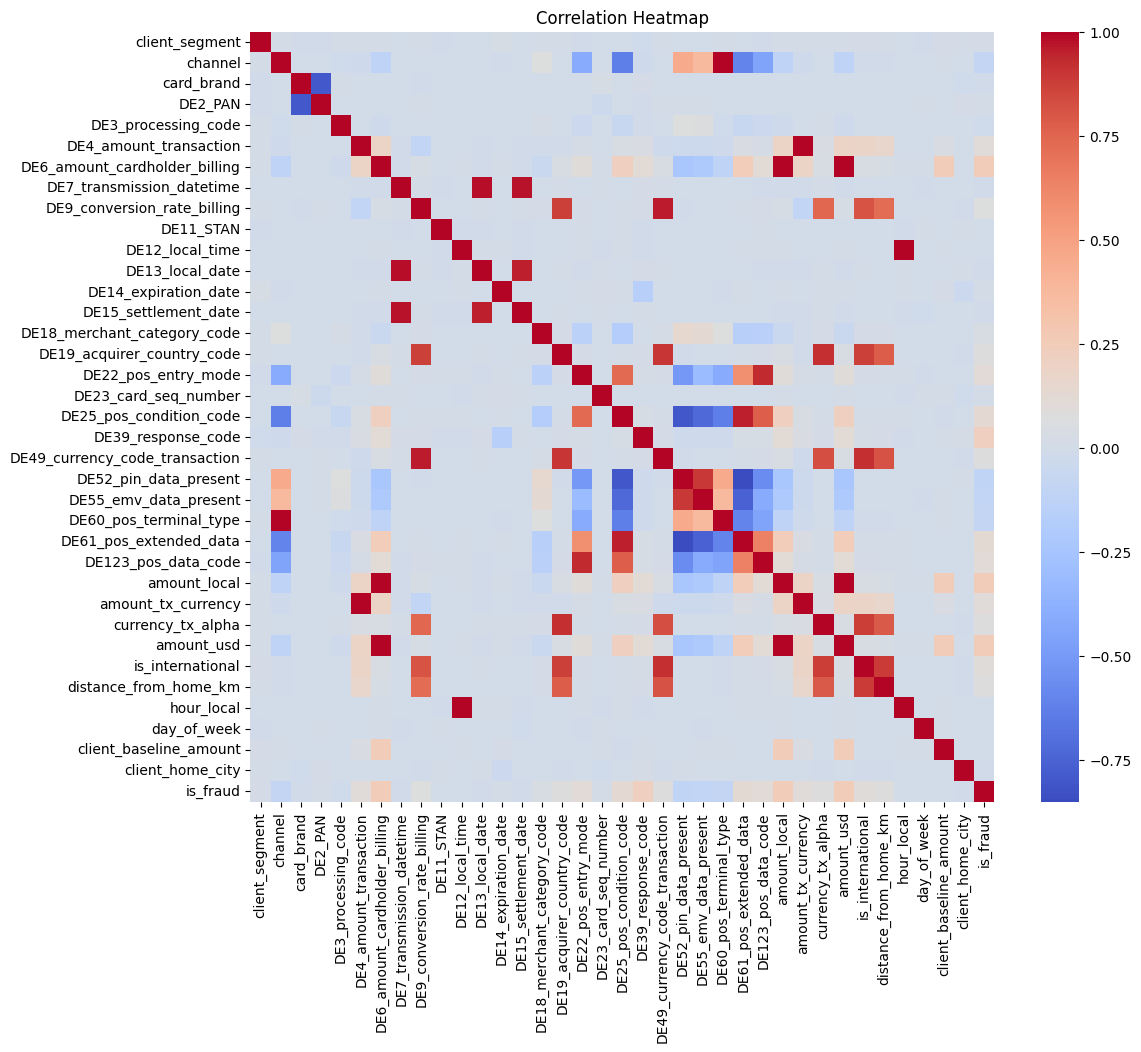

In [49]:

# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

## Exploración de relación de variables

In [44]:
# print correlation of all columns where the value of the correlation with the target variable 'is_fraud' is greater than 0.1 or less than -0.1, to see if there are any patterns in the data that could indicate that these columns are important for the model.
target_corr = df.corr()["is_fraud"].sort_values(ascending=False)
print("Columns with correlation > 0.1 or < -0.1 with target variable 'is_fraud':")
for col, corr_value in target_corr.items():
    if corr_value > 0.1 or corr_value < -0.1:
        print(f"{col}: {corr_value:.2f}")

Columns with correlation > 0.1 or < -0.1 with target variable 'is_fraud':
is_fraud: 1.00
amount_local: 0.26
DE6_amount_cardholder_billing: 0.26
amount_usd: 0.26
DE39_response_code: 0.22
DE25_pos_condition_code: 0.13
DE61_pos_extended_data: 0.12
DE123_pos_data_code: 0.11
DE22_pos_entry_mode: 0.10
DE52_pin_data_present: -0.11


In [45]:
# print all correlations with value greater than 0.1 or less than -0.1, to see if there are any patterns in the data that could indicate that these columns are important for the model.
print("All correlations with value greater than 0.1 or less than -0.1:")
all_corr = df.corr().unstack().sort_values(ascending=False)

for col, corr_value in all_corr.items():
    if corr_value > 0.1 or corr_value < -0.1:
        # print(f"{col}: {corr_value:.2f}")
        # compare both values of the tuple, if they're equal, it means that the correlation is between the same column, so we skip it
        if col[0] != col[1]:
            print(f"{col}: {corr_value:.2f}")

All correlations with value greater than 0.1 or less than -0.1:
('amount_tx_currency', 'DE4_amount_transaction'): 1.00
('DE4_amount_transaction', 'amount_tx_currency'): 1.00
('channel', 'DE60_pos_terminal_type'): 1.00
('DE60_pos_terminal_type', 'channel'): 1.00
('amount_local', 'DE6_amount_cardholder_billing'): 1.00
('DE6_amount_cardholder_billing', 'amount_local'): 1.00
('amount_usd', 'amount_local'): 1.00
('amount_local', 'amount_usd'): 1.00
('DE6_amount_cardholder_billing', 'amount_usd'): 1.00
('amount_usd', 'DE6_amount_cardholder_billing'): 1.00
('DE12_local_time', 'hour_local'): 1.00
('hour_local', 'DE12_local_time'): 1.00
('DE13_local_date', 'DE7_transmission_datetime'): 0.98
('DE7_transmission_datetime', 'DE13_local_date'): 0.98
('DE15_settlement_date', 'DE7_transmission_datetime'): 0.97
('DE7_transmission_datetime', 'DE15_settlement_date'): 0.97
('DE9_conversion_rate_billing', 'DE49_currency_code_transaction'): 0.96
('DE49_currency_code_transaction', 'DE9_conversion_rate_billin

In [50]:
# print all extreme correlations with value greater than 0.9 or less than -0.9, to see if there are any patterns in the data that could indicate that these columns are important for the model.
print("All correlations with value greater than 0.9 or less than -0.9:")
for col, corr_value in all_corr.items():
    if corr_value > 0.9 or corr_value < -0.9:
        # print(f"{col}: {corr_value:.2f}")
        # compare both values of the tuple, if they're equal, it means that the correlation is between the same column, so we skip it
        if col[0] != col[1]:
            print(f"{col}: {corr_value:.2f}")

All correlations with value greater than 0.9 or less than -0.9:
('amount_tx_currency', 'DE4_amount_transaction'): 1.00
('DE4_amount_transaction', 'amount_tx_currency'): 1.00
('channel', 'DE60_pos_terminal_type'): 1.00
('DE60_pos_terminal_type', 'channel'): 1.00
('amount_local', 'DE6_amount_cardholder_billing'): 1.00
('DE6_amount_cardholder_billing', 'amount_local'): 1.00
('amount_usd', 'amount_local'): 1.00
('amount_local', 'amount_usd'): 1.00
('DE6_amount_cardholder_billing', 'amount_usd'): 1.00
('amount_usd', 'DE6_amount_cardholder_billing'): 1.00
('DE12_local_time', 'hour_local'): 1.00
('hour_local', 'DE12_local_time'): 1.00
('DE13_local_date', 'DE7_transmission_datetime'): 0.98
('DE7_transmission_datetime', 'DE13_local_date'): 0.98
('DE15_settlement_date', 'DE7_transmission_datetime'): 0.97
('DE7_transmission_datetime', 'DE15_settlement_date'): 0.97
('DE9_conversion_rate_billing', 'DE49_currency_code_transaction'): 0.96
('DE49_currency_code_transaction', 'DE9_conversion_rate_billin

In [51]:
"""
('amount_tx_currency', 'DE4_amount_transaction'): 1.00
('channel', 'DE60_pos_terminal_type'): 1.00
('amount_local', 'DE6_amount_cardholder_billing'): 1.00
('amount_usd', 'amount_local'): 1.00
('amount_usd', 'DE6_amount_cardholder_billing'): 1.00
('hour_local', 'DE12_local_time'): 1.00
"""

# We compare the columns with extreme correlations to see if they are basically the same data represented in different ways, so we can drop some of them without losing useful information for the model. We make pairs to compare:

pairs_to_compare = [
    ("amount_tx_currency", "DE4_amount_transaction"),
    ("channel", "DE60_pos_terminal_type"),
    ("amount_local", "DE6_amount_cardholder_billing"),
    ("amount_usd", "amount_local"),
    ("amount_usd", "DE6_amount_cardholder_billing"),
    ("hour_local", "DE12_local_time")
]

# we showcase the values and distribution of values for these pairs of columns, to see if there are any patterns in the data that could indicate that these columns are important for the model.
for col1, col2 in pairs_to_compare:
    if col1 in df.columns and col2 in df.columns:
        print(f"Comparing columns: {col1} and {col2}")
        print(f" - Unique values in {col1}: {df[col1].nunique()}")
        print(f" - Unique values in {col2}: {df[col2].nunique()}")
        print(f" - Value counts for {col1}:\n{df[col1].value_counts()}")
        print(f" - Value counts for {col2}:\n{df[col2].value_counts()}")
        print("\n")

Comparing columns: amount_tx_currency and DE4_amount_transaction
 - Unique values in amount_tx_currency: 86906
 - Unique values in DE4_amount_transaction: 86906
 - Value counts for amount_tx_currency:
amount_tx_currency
2.00       41
0.26       11
67.11       7
0.56        6
0.29        6
           ..
2252.10     1
1263.82     1
5466.06     1
1081.96     1
2256.24     1
Name: count, Length: 86906, dtype: int64
 - Value counts for DE4_amount_transaction:
DE4_amount_transaction
200       41
26        11
6711       7
56         6
29         6
          ..
225210     1
126382     1
546606     1
108196     1
225624     1
Name: count, Length: 86906, dtype: int64


Comparing columns: channel and DE60_pos_terminal_type
 - Unique values in channel: 4
 - Unique values in DE60_pos_terminal_type: 4
 - Value counts for channel:
channel
1    46312
3    39128
0     9725
2     4838
Name: count, dtype: int64
 - Value counts for DE60_pos_terminal_type:
DE60_pos_terminal_type
1    46312
3    39128
0    

In [53]:
df_model = df.copy()

target = "is_fraud"

# These three pairs of columns contain the same data, so we drop the first in each pair:
# # ('amount_tx_currency', 'DE4_amount_transaction'): 1.00
# ('channel', 'DE60_pos_terminal_type'): 1.00
# ('amount_local', 'DE6_amount_cardholder_billing'): 1.00

columns_to_drop = [
    # Leakage / post-authorization result
    "DE39_response_code",
    "approved",
    "response_description",

    # Duplicates / near-duplicates
    "amount_tx_currency",
    "channel",
    "amount_local",

    # useless for modeling
    "hour_local",

]


df_model.drop(
    columns=[col for col in columns_to_drop if col in df_model.columns],
    inplace=True
)

print(df_model.shape)

(100003, 32)


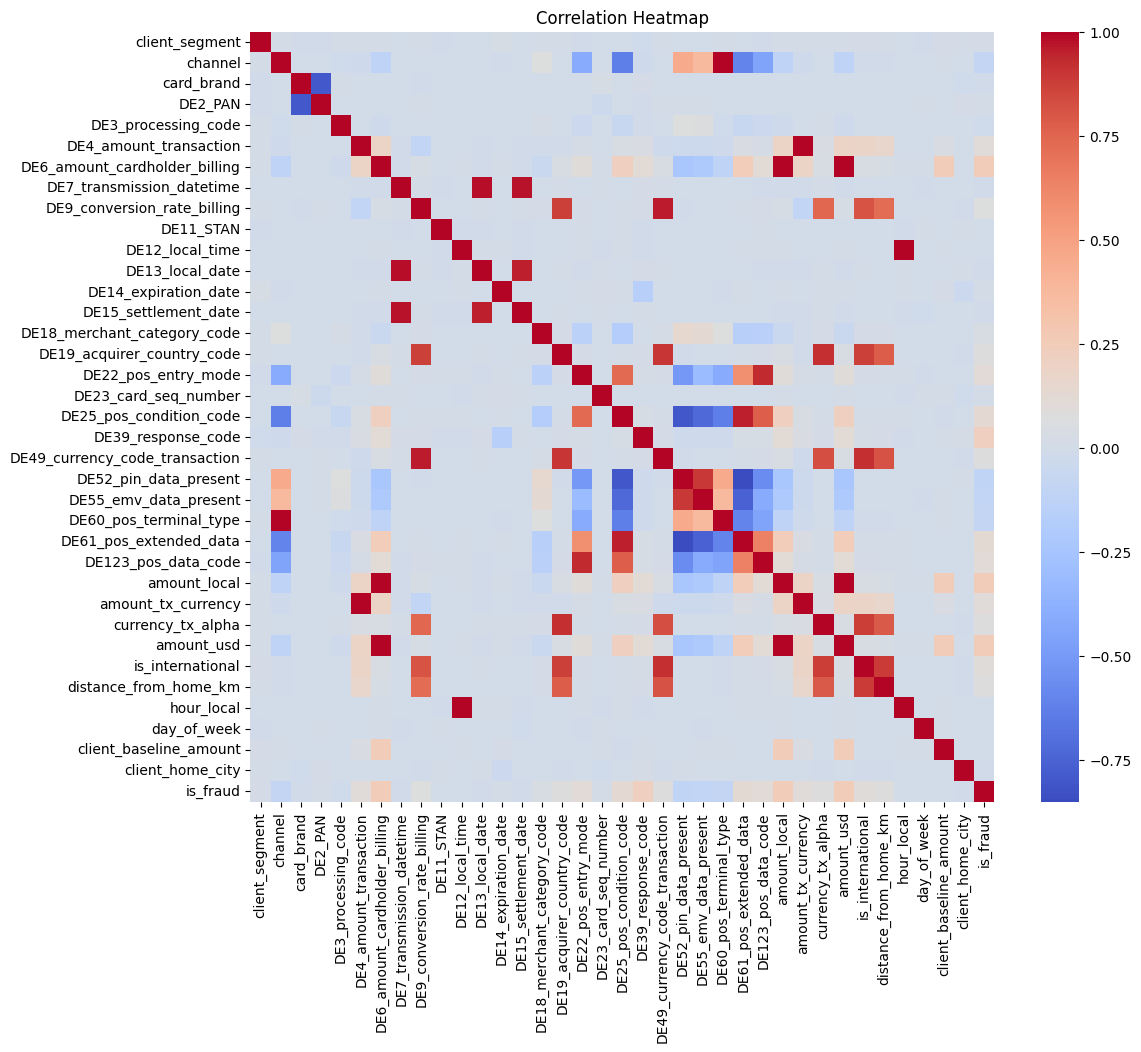

In [55]:

# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()